# Tutorial normal modes and Principal Component Analysis

### FIRST OF ALL - Run in the Linux terminal (outside the browser)

#### Activate conda enviroment

> conda activate tutorial

> cd ~/tutorial_mdenm

> jupyter-notebook tutorial_pca_modes.ipynb

## You can follow, as a guide, all the tutorial outputs from an already runned .html file 

In [3]:
system('open tutorial_pca_modes.html')


### Load bio3d and ploting libraries

In [4]:
library(bio3d)
library(ggplot2)

In [5]:
#set working directory
setwd("~/tutorial_mdenm")

In [6]:
#loading HEN EGG WHITE LYSOZYME PDB ID 2LZT
#lyso <- read.pdb ("2LZT")
lyso <- read.pdb ("lyso_ca_sse.pdb")

In [7]:
#geting calpha subset
lyso_ca <- trim.pdb(lyso, "calpha")

### Calculate protein normal modes using HCA forcefield

In [8]:
modes <- nma(lyso_ca, ff="calpha")

 Building Hessian...		Done in 0.012 seconds.
 Diagonalizing Hessian...	Done in 0.494 seconds.


In [9]:
modes


Call:
  nma.pdb(pdb = lyso_ca, ff = "calpha")

Class:
  VibrationalModes (nma)

Number of modes:
  387 (6 trivial)

Frequencies:
  Mode 7: 	0.018
  Mode 8: 	0.019
  Mode 9: 	0.024
  Mode 10: 	0.026
  Mode 11: 	0.029
  Mode 12: 	0.029

+ attr: modes, frequencies, force.constants, fluctuations,
        U, L, xyz, mass, temp, triv.modes, natoms, call

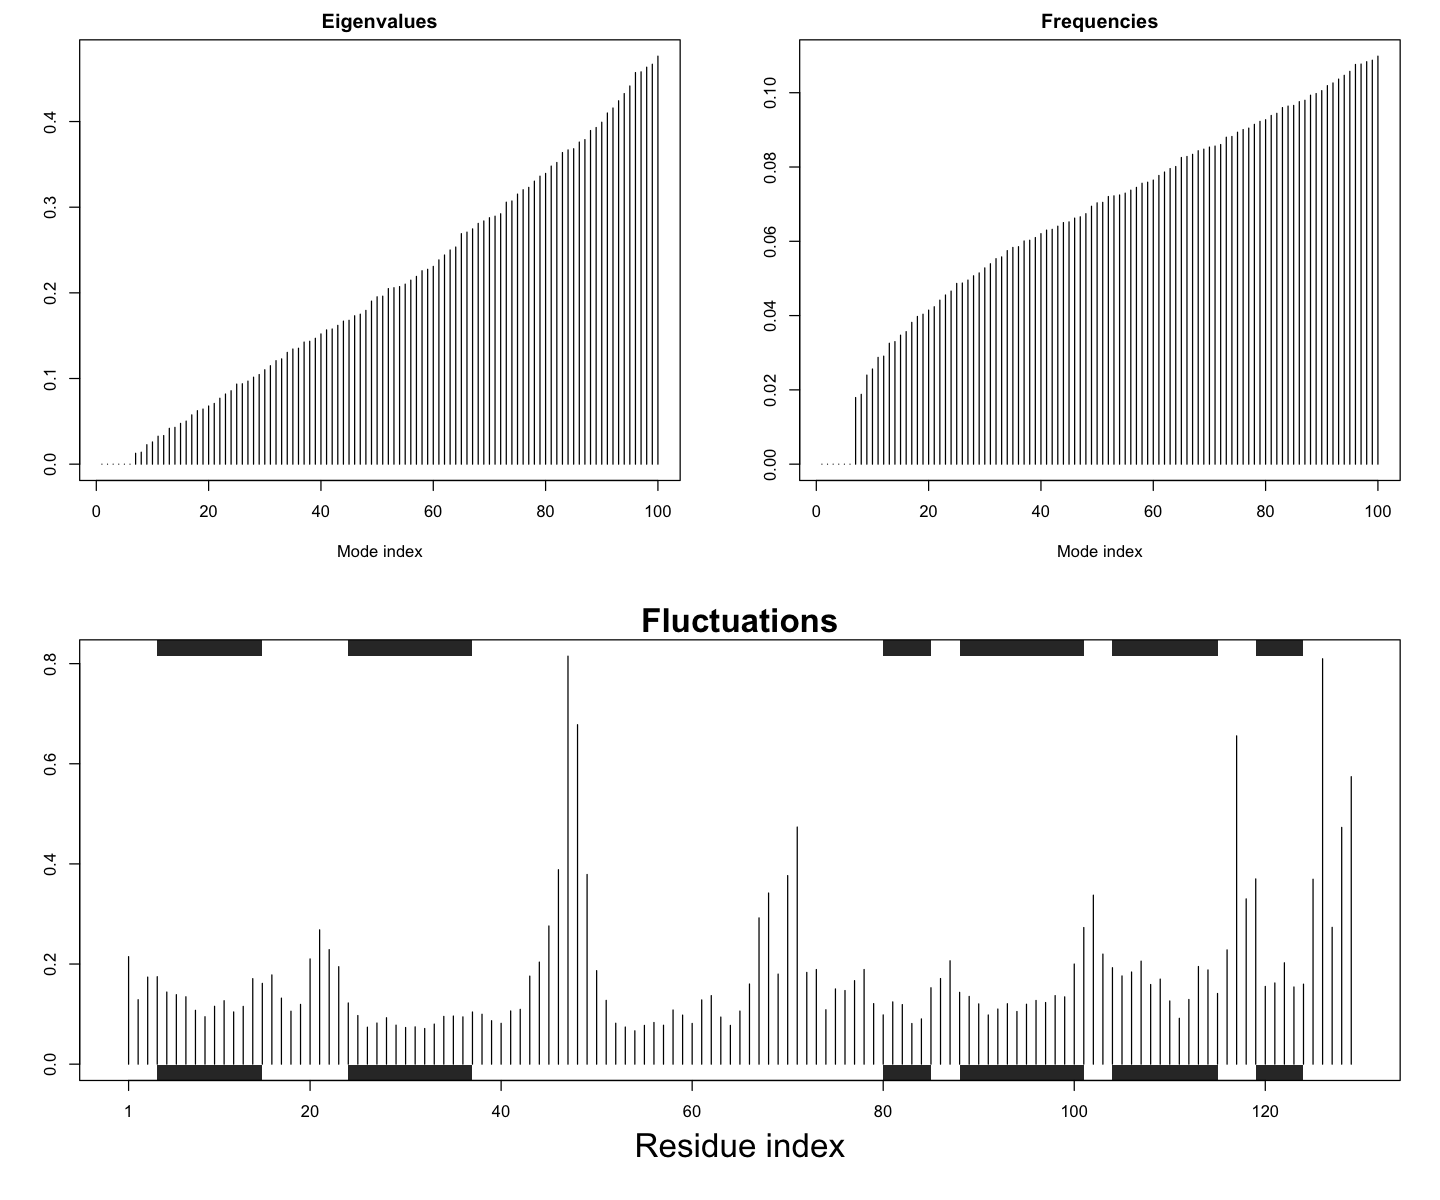

In [10]:
#ploting normal modes
options(repr.plot.width=12, repr.plot.height=10)
plot(modes, sse=lyso,  cex.lab=2, cex.axis=2, cex.main=2, cex.sub=2)

#### Visualizing normal modes directions (vectors)

In [11]:
pymol(modes, mode=7, scale=15, type="launch", exefile ="~/miniconda3/bin/pymol" )

In [12]:
pymol(modes, mode=8, scale=15, type="launch", exefile ="~/miniconda3/bin/pymol" )

#### Calculating Crosscorelation matrix from normal modes displacements

In [13]:
cm <- dccm(modes)

  |======================================================================| 100%


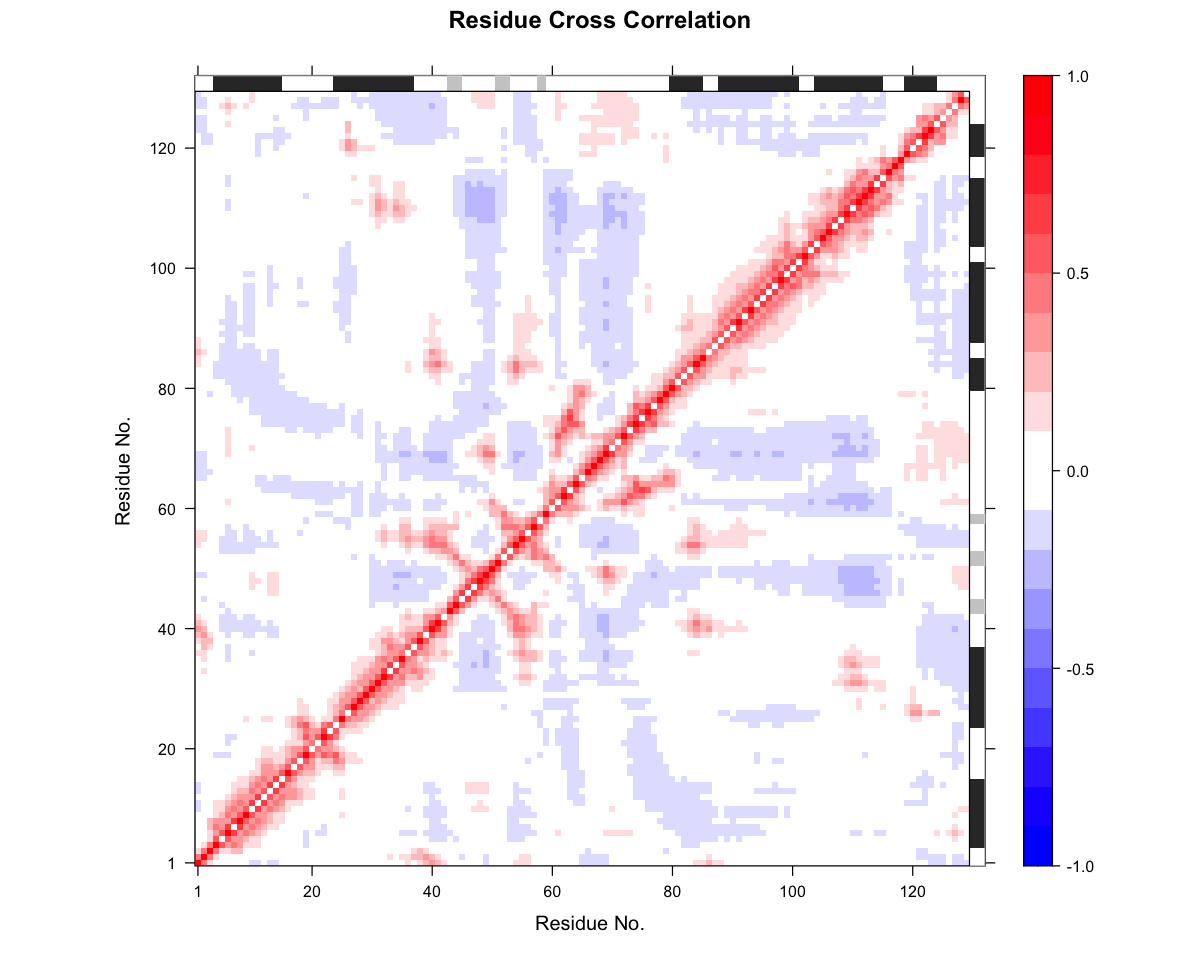

In [14]:
# Plot a correlation map with plot.dccm(cm)
options(repr.plot.width=10, repr.plot.height=8)
plot(cm, sse=lyso, contour=F, col.regions=bwr.colors(20), at=seq(-1,1,0.1))

#### Visualizing crosscorelations mapped on the lysozime structure

In [15]:
pymol(cm, lyso_ca, type="launch", exefile ="~/miniconda3/bin/pymol" )

#### Calculating normal modes fluctuations and deformation 

### Deformation energies and fluctuations calculation

Deformation analysis provides a measure for the amount of local flexibility in the protein structure - i.e. atomic motion relative to neighboring atoms. It differs from fluctuations (e.g. RMSF values) which provide amplitudes of the absolute atomic motion. Below we calculate deformation energies (with deformation.nma()) and atomic fluctuations (with fluct.nma()) of the first three modes and visualize the results in PyMOL:



In [16]:
#Deformation
defe <- deformation.nma(modes)
defsums <- rowSums(defe$ei[,1:3])

In [17]:
#Fluctuations
flucts <- fluct.nma(modes, mode.inds=seq(7,9))

In [18]:
# Write to PDB files (see Figure 6.)
write.pdb(pdb=NULL, xyz=modes$xyz, file="R-defor.pdb", b=defsums)
write.pdb(pdb=NULL, xyz=modes$xyz, file="R-fluct.pdb", b=flucts)


#### Open the "R-defor.pdb" and "R-fluct.pdb" with Pymol

#### Deformation


In [19]:
#pymol R-defor.pdb
#Actions (A)
    #Preset
        #B factor putty

<img src="deformation.png" width="600" align='center'>




#### Fluctuations

In [20]:
#pymol R-fluct.pdb
#Actions (A)
    #Preset
        #B factor putty

<img src="fluctuations.png" width="600" align='center'>

## Dynamical Domain Assignment from normal modes

In [21]:
gs <- geostas(modes, m.inds = 7:11, verbose=TRUE)
gs

  .. generating trajectory from 5 modes
  .. 'xyz' coordinate data with 85 frames 
  .. 'fit=TRUE': running function 'core.find'
  .. coordinates are superimposed to core region
  .. calculating atomic movement similarity matrix ('amsm.xyz()') 
  .. dimensions of AMSM are 129x129
  .. clustering AMSM using 'kmeans' 



Call:
  geostas.xyz(xyz = trj, verbose = verbose)

Class:
  geostas

Dimensions of AMSM:
  129x129

Number of domains:
  3

Domain size:
  #1: 34 atoms 
  #2: 54 atoms 
  #3: 41 atoms 

+ attr: call, amsm, fit.inds, grps, inds

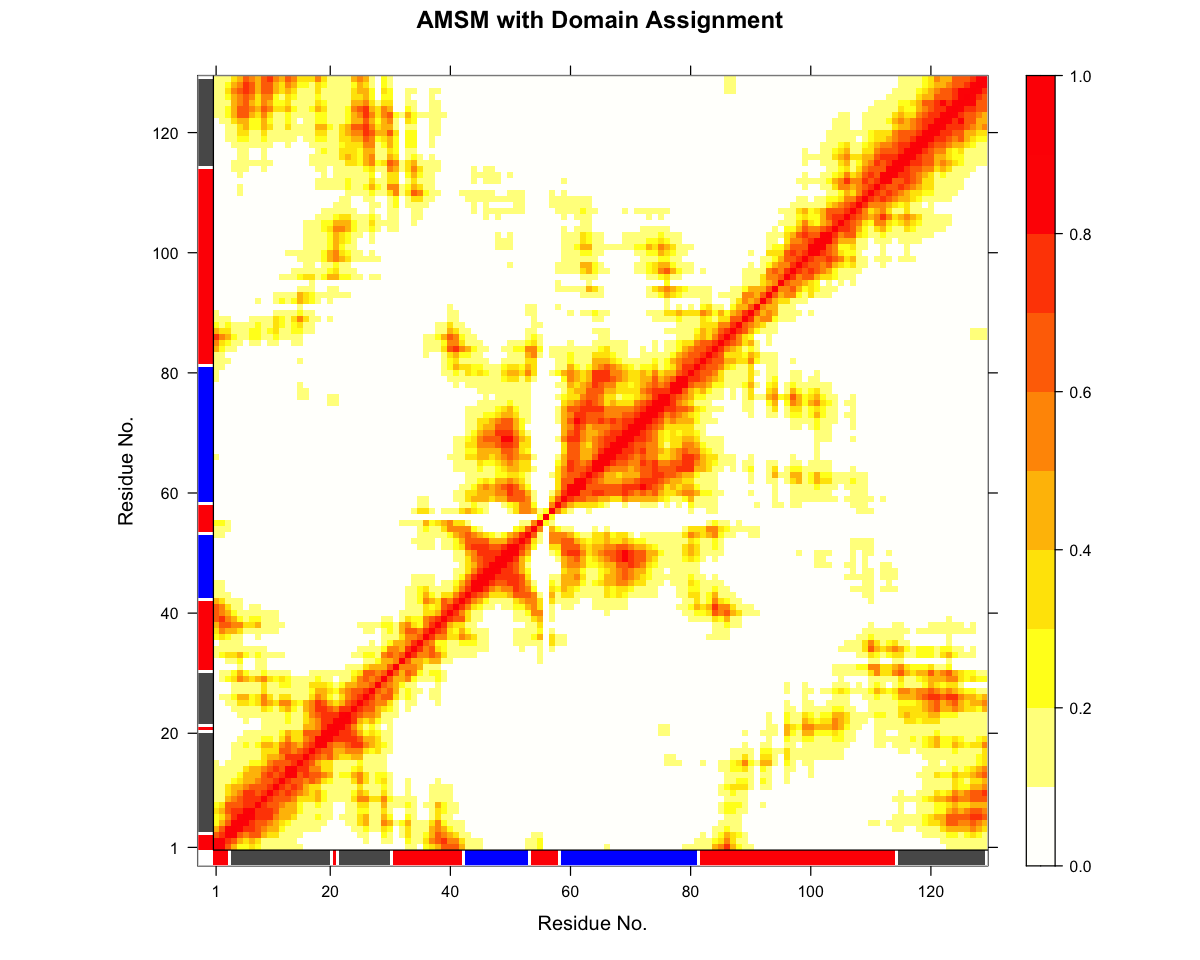

In [22]:
# Plot a atomic movement similarity matrix
plot(gs, margin.segments=gs$grps, contour=FALSE)


In [23]:
#Generating normal mode trajectory with the protein chain ID assigned for each dynamical domain
mktrj(modes, mode=7, chain=gs$grps)

##### Open the terminal and run the vmd
$ vmd mode_7.pdb
   
   Graphics --> Representation
   
       Drawing Method --> tube  
       
       Coloring Method --> chain
   
        

<img src="geostat.png" width="600" align='center'>

## Create an experimental ensemble of lysozyme related structures from PDB

In [24]:
exp <- read.dcd("experimental_lyso_814s.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 814 
 ISTART= 0 
 last  = 814 
 nstep = 814 
 nfile = 814 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [25]:
# Calculate pair-wised RMSD
rd <- rmsd(exp)
#RMSD Clustering
hc.rd <- hclust(dist(rd), method="single")
grps.rd <- cutree(hc.rd, k=2)

Warning message in rmsd(exp):
“No indices provided, using the 129 non NA positions
”


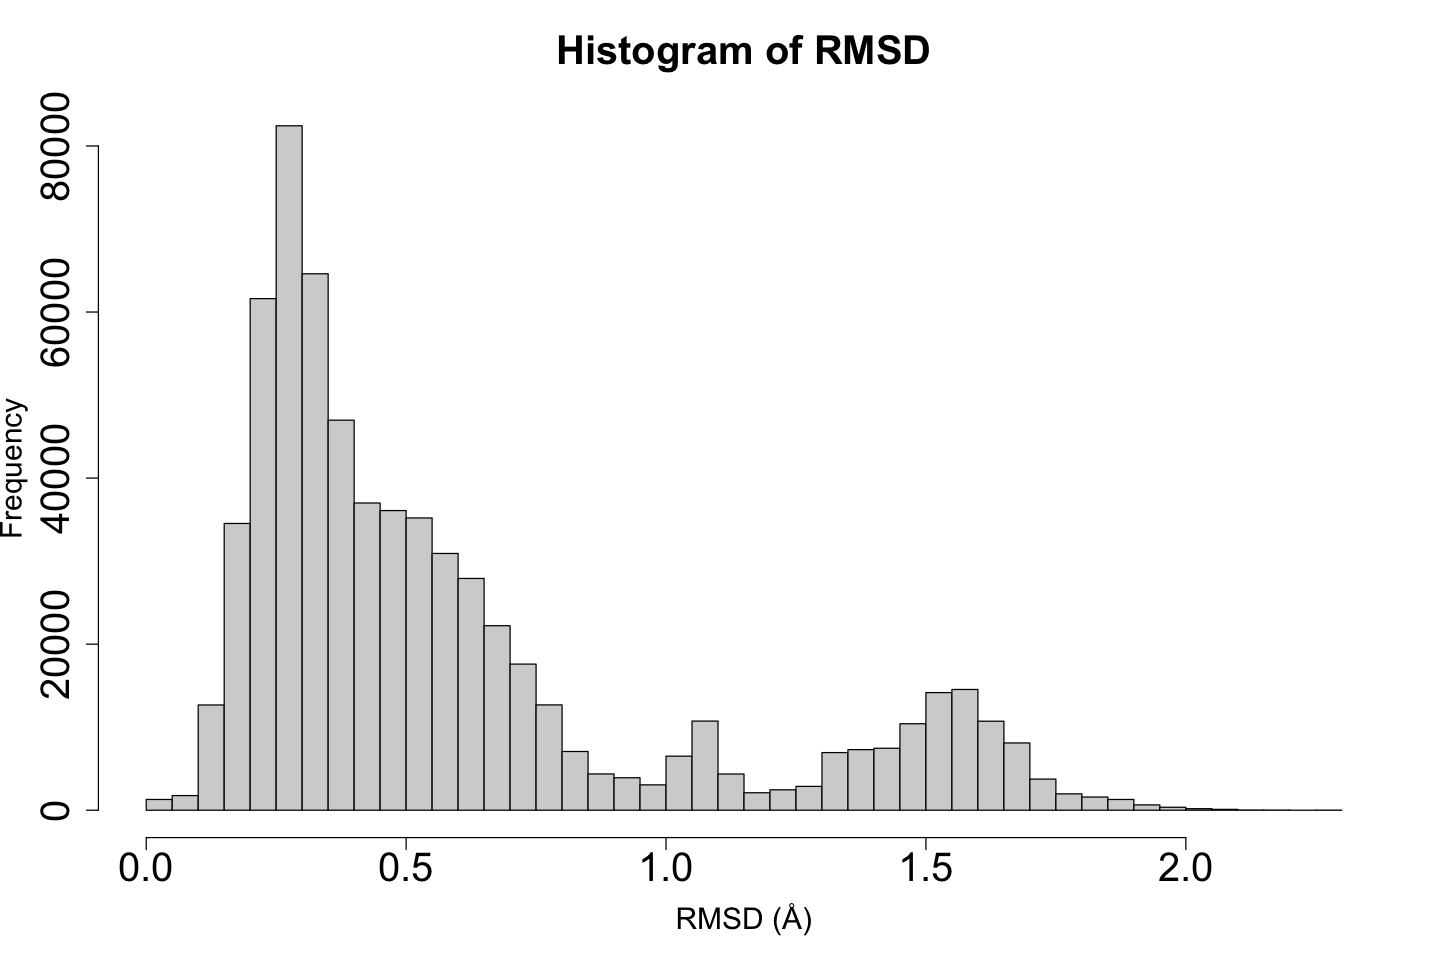

In [26]:
#Ploting the pairwise RMSD histogram
options(repr.plot.width=12, repr.plot.height=8)
hist(rd, breaks=40, xlab="RMSD (Å)", main="Histogram of RMSD", cex.lab=1.5, cex.axis=2, cex.main=2, cex.sub=2)

#### Perform PCA of the experimental ensemble

In [27]:
#fit structures onto reference
exp_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = exp)
#perform Principal Component Analysis (PCA)
pca_exp <- pca.xyz(use.svd = T, xyz = exp_fit)

Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = exp):
“No fitting indices provided, using the 129 non NA positions
”


In [28]:
pca_exp


Call:
  pca.xyz(xyz = exp_fit, use.svd = T)

Class:
  pca

Number of eigenvalues:
  387

        Eigenvalue Variance Cumulative
   PC 1     15.671   44.188     44.188
   PC 2      3.531    9.956     54.144
   PC 3      2.245    6.331     60.475
   PC 4      2.133    6.014     66.489
   PC 5      1.575    4.442     70.931
   PC 6      0.962    2.713     73.643

   (Obtained from 814 conformers with 387 xyz input values).

+ attr: L, U, z, au, sdev, mean, call

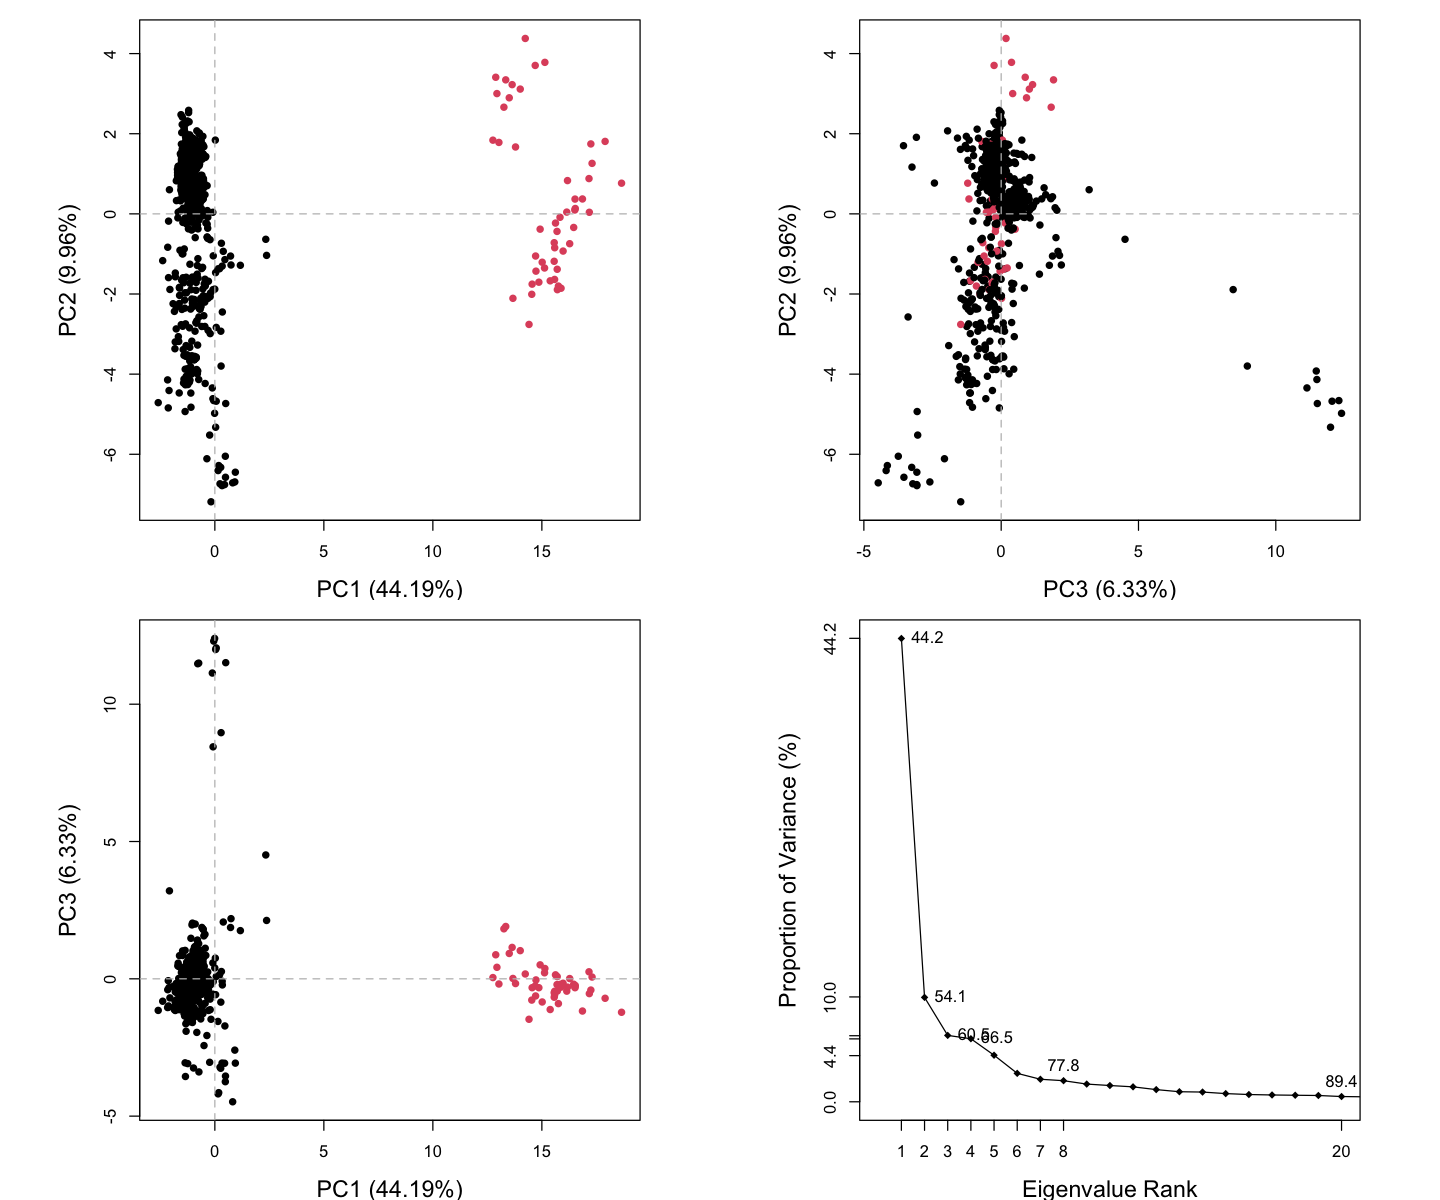

In [29]:
# ploting PCs colored by RMS-clustered groups
options(repr.plot.width=12, repr.plot.height=10)
plot.pca(pca_exp, col=grps.rd, cex.lab=1.4, cex.main=2, cex.sub=2)

#### Visualizing principal component (PC) directions (vectors)

In [30]:
pymol(pca_exp, mode=1, scale=30, dual=F, type="launch", exefile ="~/miniconda3/bin/pymol" )

In [31]:
pymol(pca_exp, mode=2, scale=30, dual=F, type="launch", exefile ="~/miniconda3/bin/pymol" )

#### Ploting PC fluctuations (PC1 and PC2)

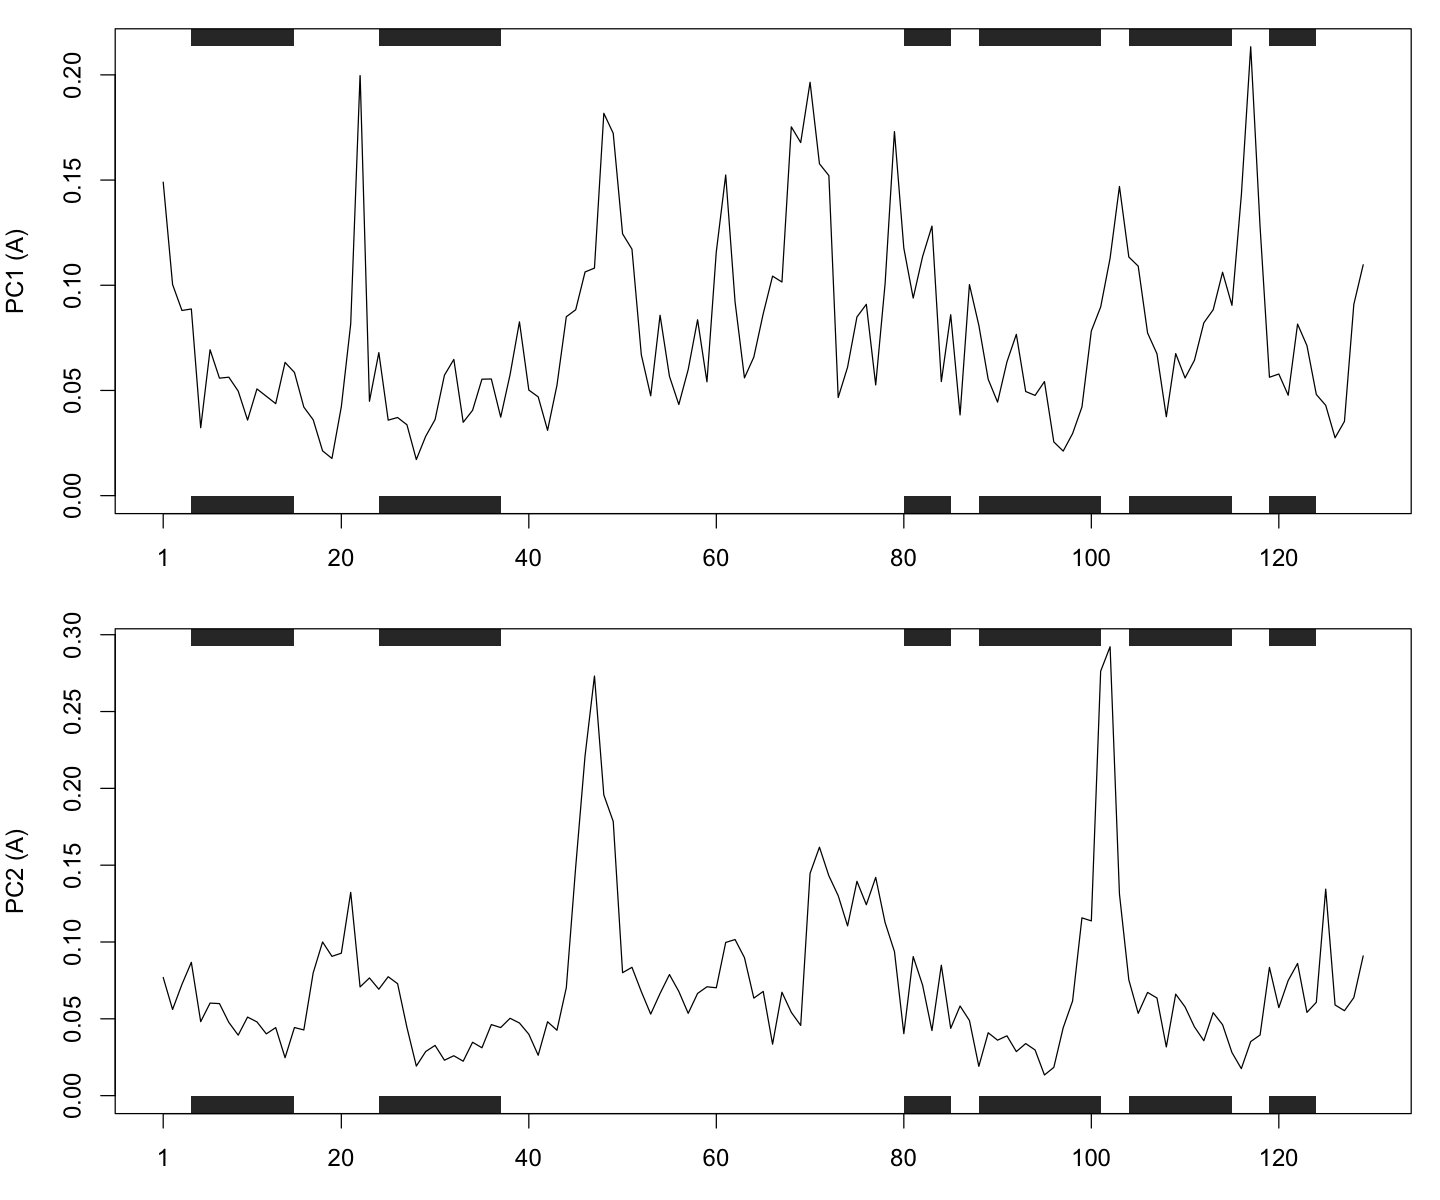

In [32]:
op <- par(no.readonly=TRUE)
par(mfrow = c(2, 1), cex = 1.2, mar = c(3, 4, 1, 1))
plot.bio3d(pca_exp$au[,1], ylab="PC1 (A)", sse=lyso, type="l" )
plot.bio3d(pca_exp$au[,2], ylab="PC2 (A)", sse=lyso, type="l")


### Comparing Normal modes with PCs from the experimental ensemble

In [33]:
# Calculating overlaproot mean square inner products of NM with PCs
rmsip <- rmsip(modes, pca_exp)

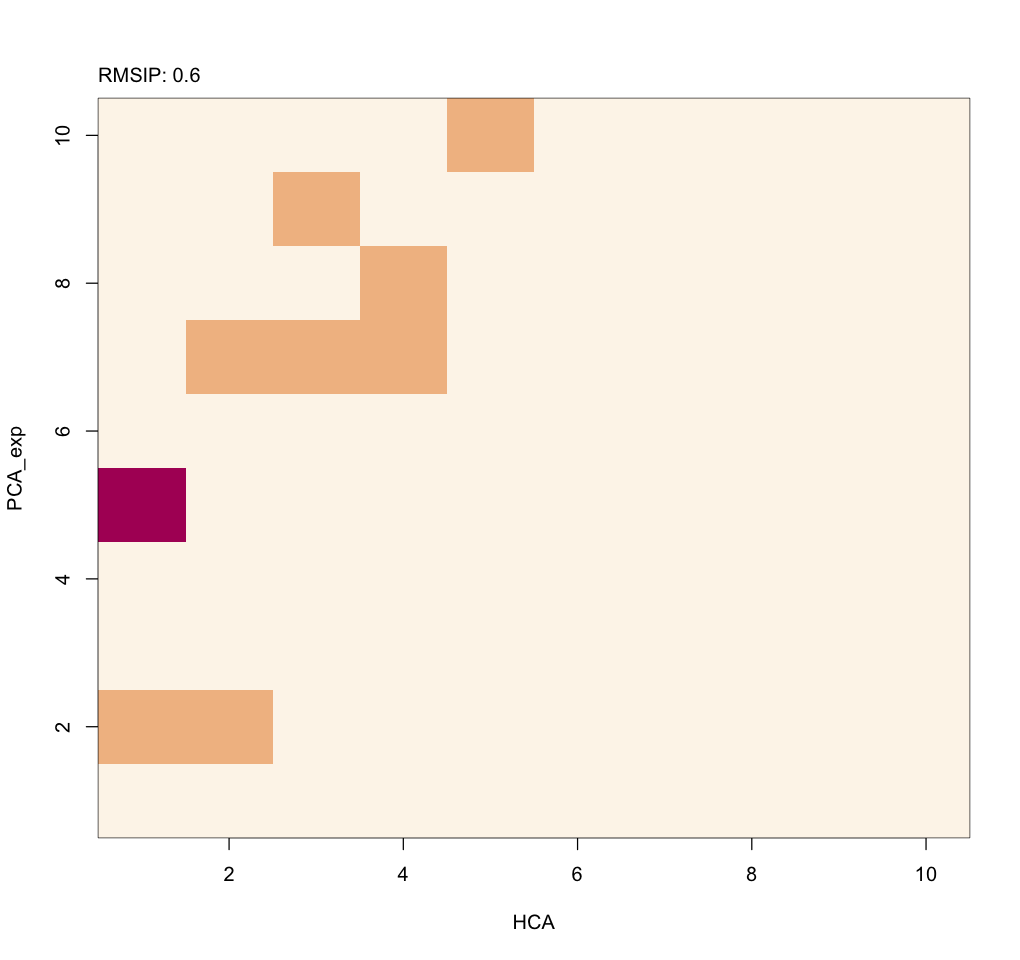

In [34]:
options(repr.plot.width=8.5, repr.plot.height=8)
plot(rmsip, xlab="HCA", ylab="PCA_exp", col=hcl.colors(10,"Rock", rev=T))

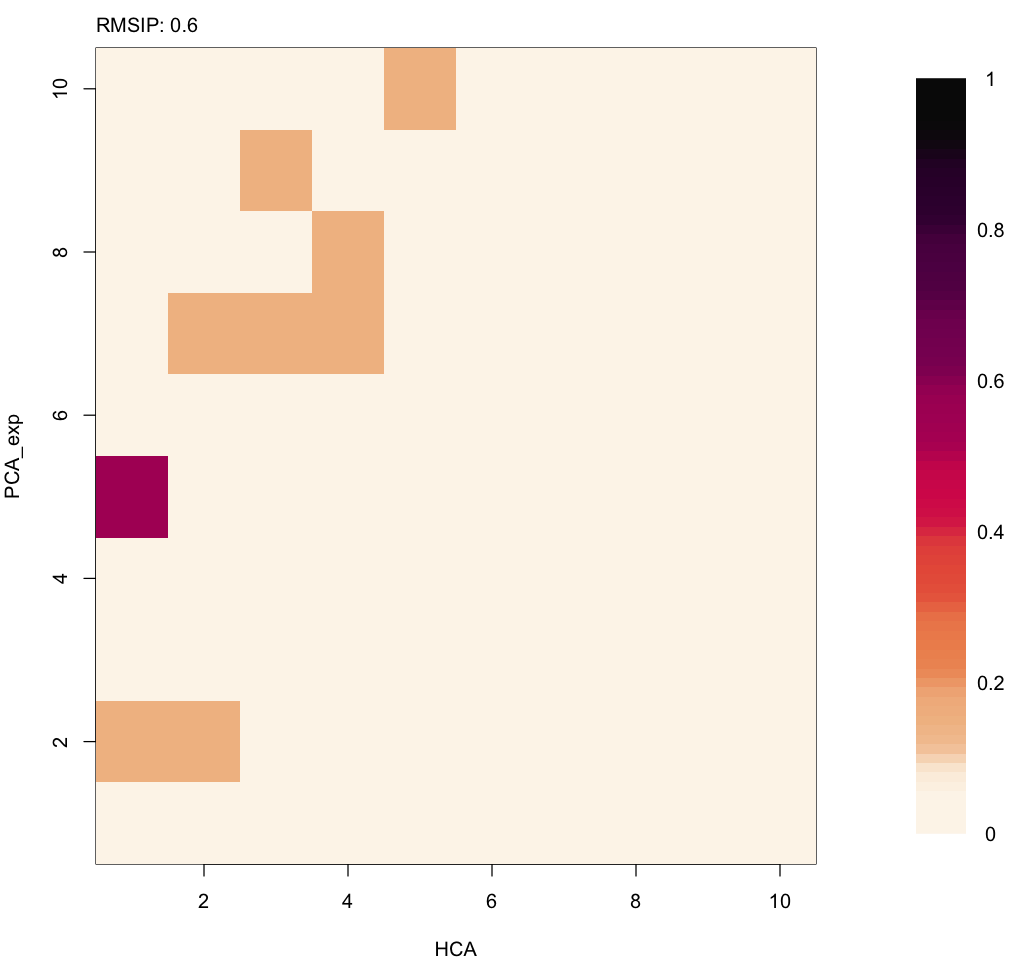

In [35]:
#Ploting the overlap colored heatmap with the scale bar
par(mar=c(4,4,2,0))
par(fig=c(0,8,0,10)/10)
plot(rmsip, xlab="HCA", ylab="PCA_exp", col=hcl.colors(10,"Rock", rev=T))
par(fig=c(8,10,0,10)/10)
par(new=T)
legend_image <- as.raster(matrix(hcl.colors(10,"Rock"), ncol=1))
plot(c(0,2),c(0,1),type = 'n', axes = F,xlab = '', ylab = '', main = '')
text(x=1.5, y = seq(0,1,l=6), labels = seq(0,1,l=6))
rasterImage(legend_image, 1, 0, 0,1)


### Analyses of the 1 microsecond MD simulation of Lysozime

In [36]:
#Load the prerunned MD simulation trajectory
md <-read.dcd("lyso_2019_md_fit_CA.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 10000 
 ISTART= 0 
 last  = 10000 
 nstep = 10000 
 nfile = 10000 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [37]:
mdskip <-read.dcd("md_skip.dcd")

Warning message in dcd.header(trj, verbose):
“Check DCD header data is correct, particulary natom”


 NATOM = 129 
 NFRAME= 1000 
 ISTART= 0 
 last  = 1000 
 nstep = 1000 
 nfile = 1000 
 NSAVE = 1 
 NDEGF = 0 
 version 24 
  |======================================================================| 100%


In [38]:
rd_md <- rmsd(mdskip)

Warning message in rmsd(mdskip):
“No indices provided, using the 129 non NA positions
”


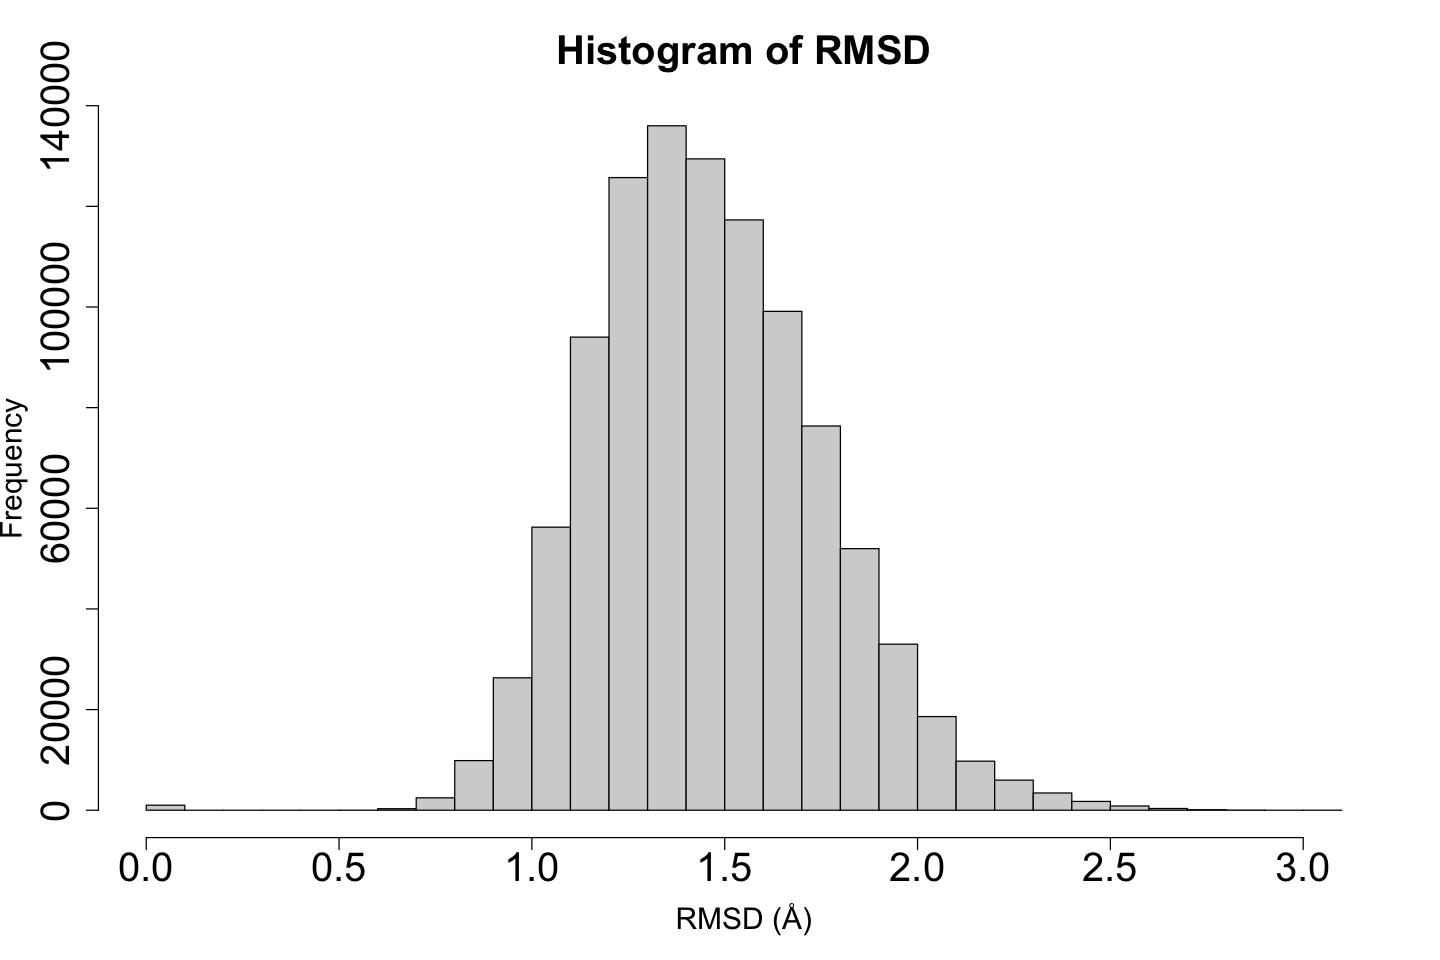

In [39]:
options(repr.plot.width=12, repr.plot.height=8)
hist(rd_md, breaks=40, xlab="RMSD (Å)", main="Histogram of RMSD", cex.lab=1.5, cex.axis=2, cex.main=2, cex.sub=2)

In [40]:

#Concatenating MD and exp trajectories
traj <- rbind(md,exp)

In [41]:
traj_fit <- fit.xyz(fixed = lyso_ca$xyz, mobile = traj)

Warning message in fit.xyz(fixed = lyso_ca$xyz, mobile = traj):
“No fitting indices provided, using the 129 non NA positions
”


In [42]:
#Calculating the PCA for the concatenated trajectory (MD + exp)
pca_all <- pca.xyz(traj_fit, use.svd = T)

In [43]:
#Creating groups (factors) to plot with different colors
md_frames <- dim(md)[1]
exp_frames <- dim(exp)[1]
grp_traj <- c(rep(1, md_frames), rep(2, exp_frames))

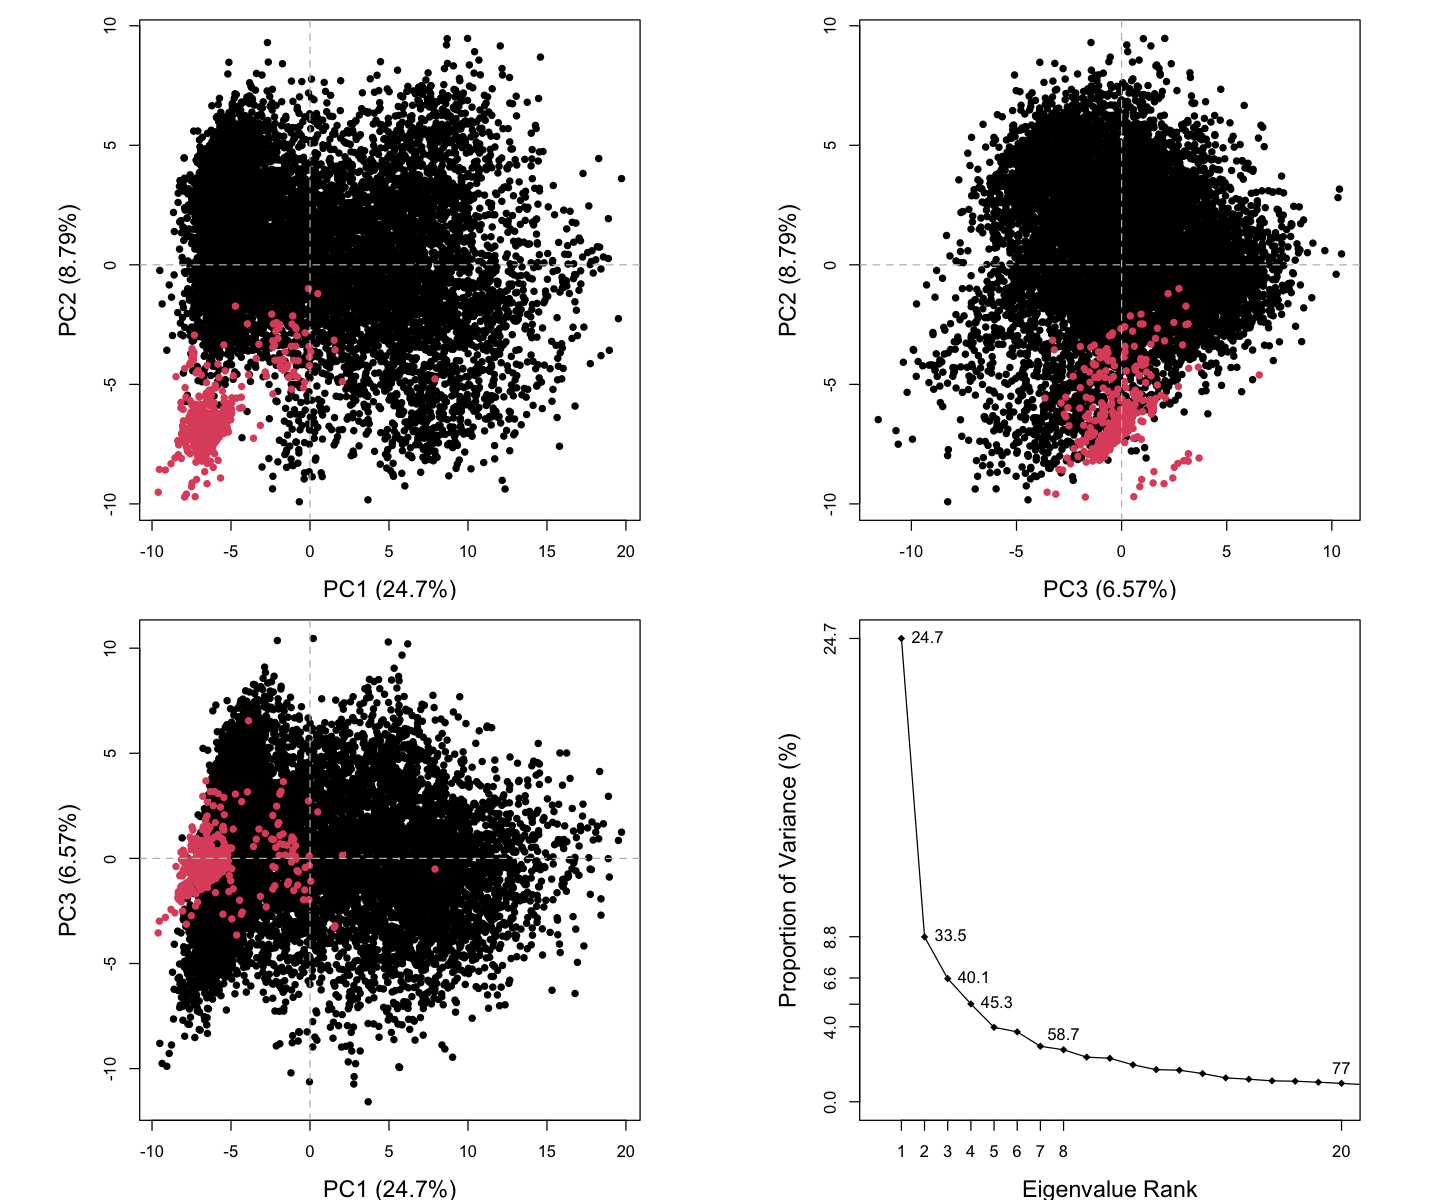

In [44]:
#Ploting both MD (black) and experimental (red) structures onto the PCs
options(repr.plot.width=12, repr.plot.height=10)
plot.pca(pca_all, col=grp_traj, cex.lab=1.4, cex.main=2, cex.sub=2)

In [45]:
#Visualize in pymol the PC5, which corresponds to the normal mode 1 (hinge motion)
pymol(pca_all, mode=5, scale=20, type="launch", exefile ="~/miniconda3/bin/pymol" )

In [46]:
data <- data.frame(pca_all$z, factor= c(rep("MD", md_frames), rep("exp", exp_frames)))

In [47]:
df_md <-data[data$factor == 'MD', ]
df_exp <-data[data$factor == 'exp', ]

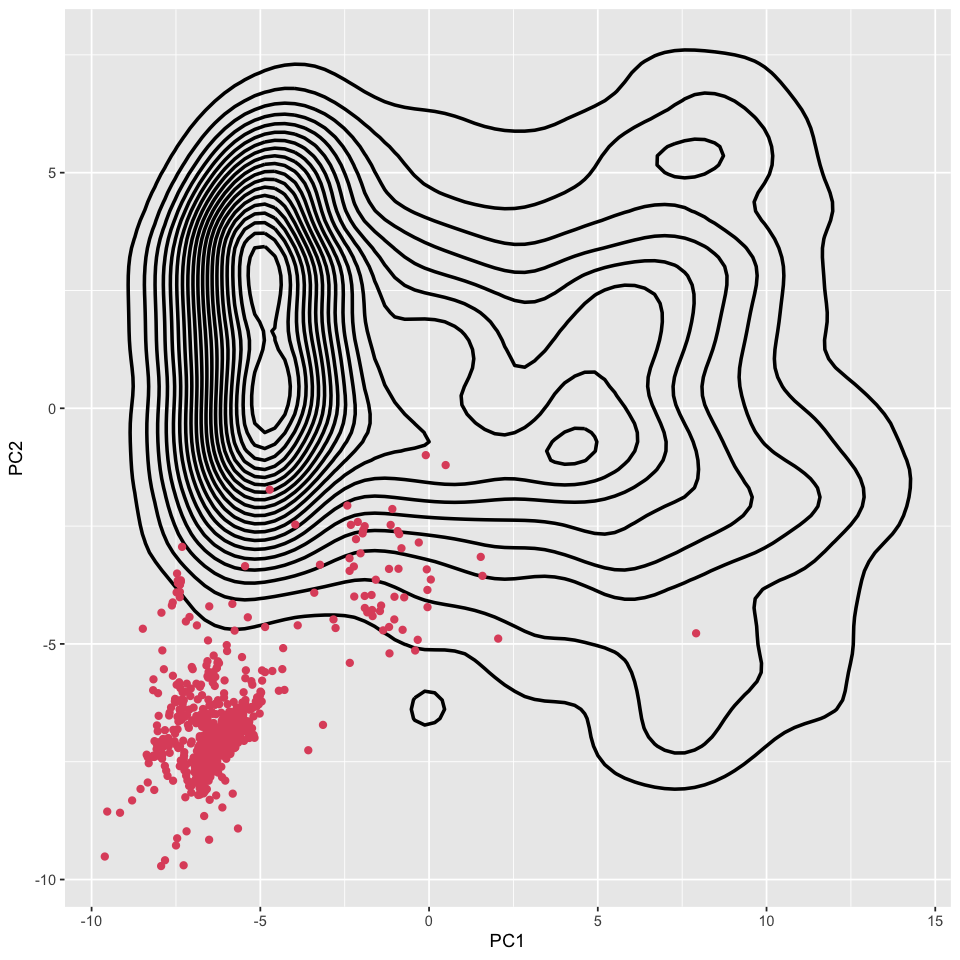

In [48]:
#Ploting the trajectories projections onto PC1 and PC2 (same data from the top plot of the previous figure)
#MD is respresent as contour levels
#exp structures as points
options(repr.plot.width=8, repr.plot.height=8)
ggplot() +
 stat_density_2d(aes(x=df_md$X1, y=df_md$X2), linewidth=1, 
                  contour_var = "ndensity", h=NULL,color="black", bins=20) +
 geom_point(aes(x=df_exp$X1, y=df_exp$X2), color="#DF536B", size=2, shape=16)   +
xlab ("PC1") + ylab("PC2")